In [2]:
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install wordcloud -q
!pip install contractions -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 37.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.0 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions
from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


# **understanding the dataset**

In [6]:
import zipfile

zip_path = "/content/8. Sarcastic or Not Sarcastic Dataset-20260504T014731Z-3-001.zip"
extract_path = "/content/sarcasm_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [7]:
df = pd.read_csv("/content/sarcasm_data/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv")
print(df.head())

                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1


In [8]:
print("Shape:", df.shape)
print(df.head())
print("\nClass distribution:")
print(df['is_sarcastic'].value_counts())

Shape: (28619, 2)
                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1

Class distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


# **cleaning the data**

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Expand contractions (don't → do not)
    text = contractions.fix(text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags (#word)
    text = re.sub(r'#\w+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters & punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['cleaned'] = df['headline'].apply(clean_text)

print("\nSample cleaned headlines:")
print(df[['headline', 'cleaned', 'is_sarcastic']].head(5).to_string())


Sample cleaned headlines:
                                                                          headline                                                             cleaned  is_sarcastic
0                    thirtysomething scientists unveil doomsday clock of hair loss           thirtysomething scientist unveil doomsday clock hair loss             1
1  dem rep. totally nails why congress is falling short on gender, racial equality  dem rep totally nail congress falling short gender racial equality             0
2                                eat your veggies: 9 deliciously different recipes                             eat veggie deliciously different recipe             0
3                             inclement weather prevents liar from getting to work                        inclement weather prevents liar getting work             1
4                    mother comes pretty close to using word 'streaming' correctly             mother come pretty close using word streaming correct

# **Visualizing the cleaned data**

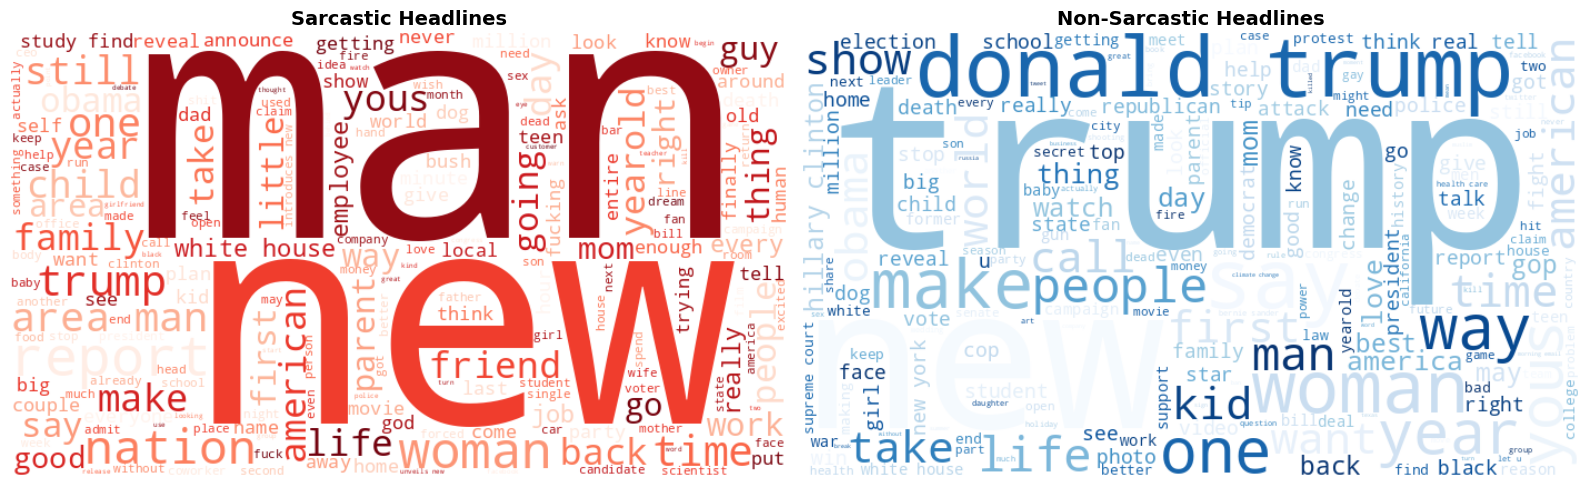

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word Cloud - Sarcastic
sarcastic_text = ' '.join(df[df['is_sarcastic'] == 1]['cleaned'])
wc1 = WordCloud(width=700, height=400, background_color='white', colormap='Reds').generate(sarcastic_text)
axes[0].imshow(wc1, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Sarcastic Headlines', fontsize=14, fontweight='bold')

# Word Cloud - Non-Sarcastic
non_sarcastic_text = ' '.join(df[df['is_sarcastic'] == 0]['cleaned'])
wc2 = WordCloud(width=700, height=400, background_color='white', colormap='Blues').generate(non_sarcastic_text)
axes[1].imshow(wc2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Non-Sarcastic Headlines', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

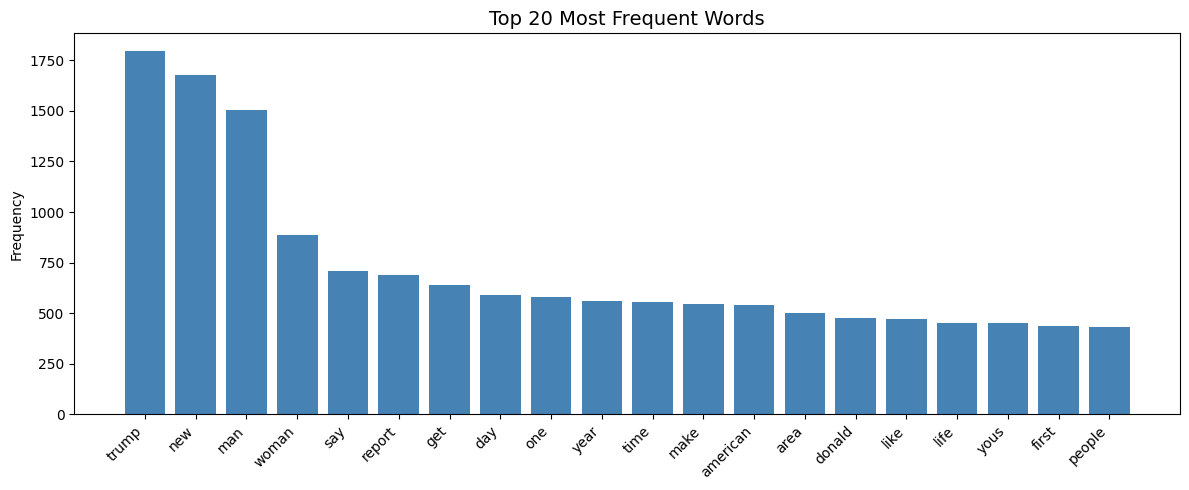

In [11]:
all_words = ' '.join(df['cleaned']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words', fontsize=14)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# **Tokenizing, padding and splitting**

In [12]:
X = df['cleaned'].values
y = df['is_sarcastic'].values

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 22895 | Test size: 5724


In [13]:
VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")

Vocabulary size: 22523


In [14]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [15]:
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max sequence length (95th percentile): {MAX_LEN}")

Max sequence length (95th percentile): 11


In [16]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape:  {X_test_pad.shape}")

X_train_pad shape: (22895, 11)
X_test_pad shape:  (5724, 11)


In [17]:
EMBEDDING_DIM = 64

# **Model building**

In [21]:
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dense(1, activation='sigmoid')
], name='SimpleRNN_Model')

model1.build(input_shape=(None, MAX_LEN))
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,321 (4.91 MB)

 Trainable params: 1,288,321 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='LSTM_Model')

model2.build(input_shape=(None, MAX_LEN))
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,382,977 (5.28 MB)

 Trainable params: 1,382,977 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import gensim.downloader as api

embedding_model = api.load('word2vec-google-news-300')
EMBEDDING_DIM_W2V = 300

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_W2V))
found = 0
for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

print(f"Words covered by word2vec embeddings: {found}/{min(len(word_index), VOCAB_SIZE)}")

Words covered by word2vec embeddings: 16268/20000


In [19]:
model3 = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM_W2V,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ),
    LSTM(128),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='LSTM_Word2vec_Model')

model3.build(input_shape=(None, MAX_LEN))
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Word2vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 300)        │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,223,809 (23.74 MB)

 Trainable params: 6,223,809 (23.74 MB)

 Non-trainable params: 0 (0.00 B)

# **Compiling and training**

In [23]:
# Compile all models
for model in [model1, model2, model3]:
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
EPOCHS = 15
BATCH_SIZE = 64

In [25]:
print("\n--- Training Model 1: SimpleRNN ---")
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop], verbose=1
)


--- Training Model 1: SimpleRNN ---
Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7529 - loss: 0.4928 - val_accuracy: 0.8166 - val_loss: 0.4224
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9275 - loss: 0.1930 - val_accuracy: 0.8070 - val_loss: 0.4559
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9793 - loss: 0.0608 - val_accuracy: 0.7987 - val_loss: 0.6377


In [26]:
print("\n--- Training Model 2: LSTM ---")
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop], verbose=1
)


--- Training Model 2: LSTM ---
Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7470 - loss: 0.5002 - val_accuracy: 0.7961 - val_loss: 0.4409
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8841 - loss: 0.2793 - val_accuracy: 0.7895 - val_loss: 0.4553
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9284 - loss: 0.1843 - val_accuracy: 0.7843 - val_loss: 0.5479


In [24]:
print("\n--- Training Model 3: LSTM + word2vec ---")
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop], verbose=1
)


--- Training Model 3: LSTM + word2vec ---
Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7710 - loss: 0.4671 - val_accuracy: 0.7904 - val_loss: 0.4269
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8967 - loss: 0.2543 - val_accuracy: 0.8293 - val_loss: 0.3899
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9543 - loss: 0.1243 - val_accuracy: 0.8210 - val_loss: 0.4927
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9783 - loss: 0.0639 - val_accuracy: 0.8183 - val_loss: 0.6641
Epoch 5/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9902 - loss: 0.0321 - val_accuracy: 0.8175 - val_loss: 0.7420


# **visualizing loss and accuracy**

In [27]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

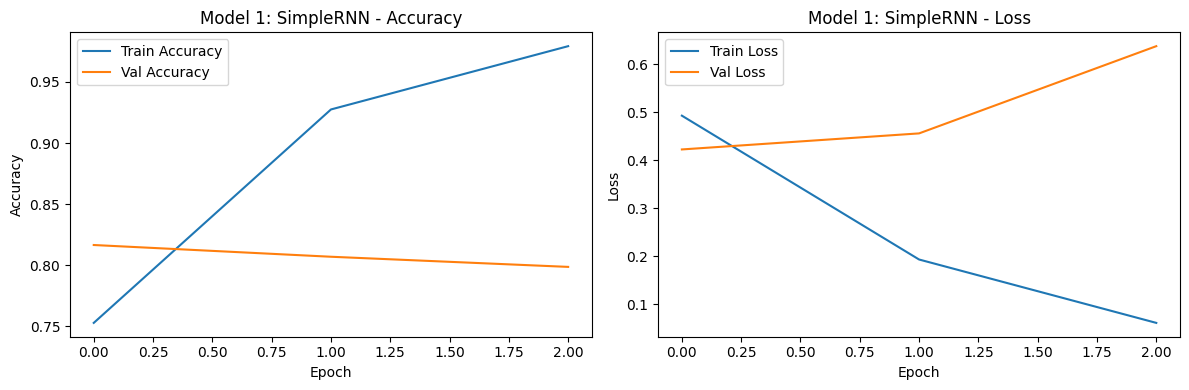

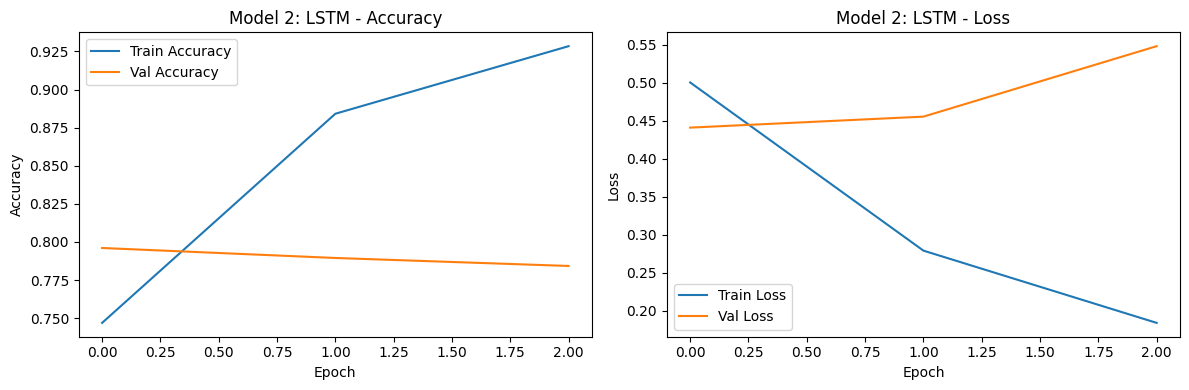

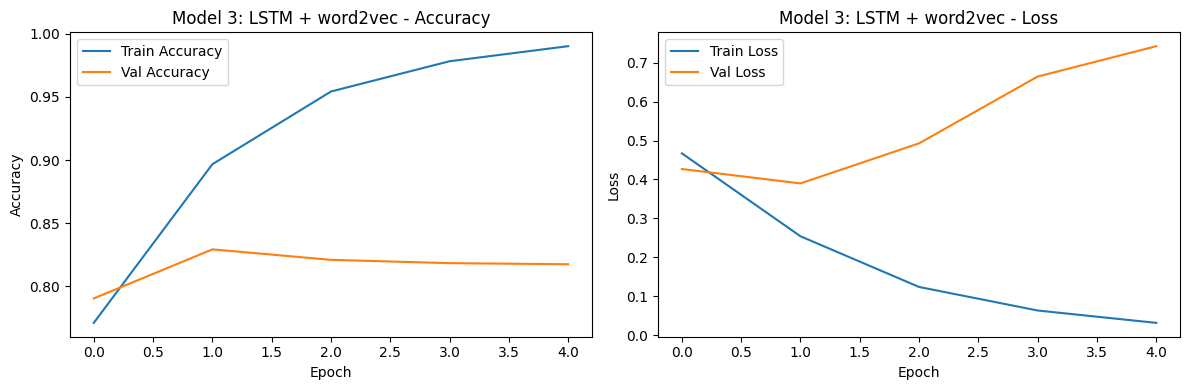

In [28]:
plot_history(history1, 'Model 1: SimpleRNN')
plot_history(history2, 'Model 2: LSTM')
plot_history(history3, 'Model 3: LSTM + word2vec')

# **Evaluating models**

In [29]:
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print('='*50)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")

    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Sarcastic', 'Sarcastic'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Classification Report
    print(classification_report(y_test, y_pred, target_names=['Not Sarcastic', 'Sarcastic']))

    return y_pred, acc


Evaluation: Model 1: SimpleRNN
Test Accuracy: 0.7979 | Test Loss: 0.4386
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


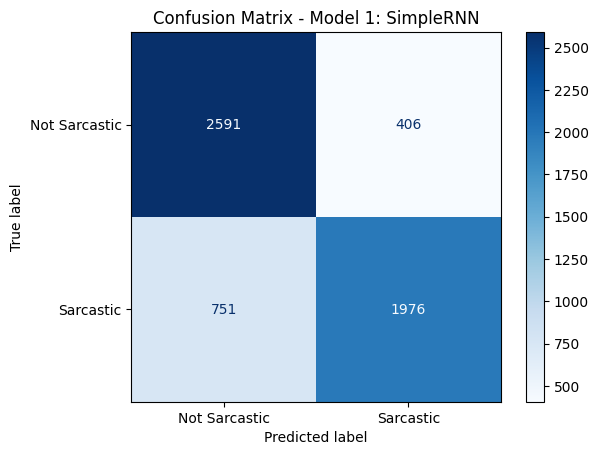

               precision    recall  f1-score   support

Not Sarcastic       0.78      0.86      0.82      2997
    Sarcastic       0.83      0.72      0.77      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.79      0.80      5724
 weighted avg       0.80      0.80      0.80      5724


Evaluation: Model 2: LSTM
Test Accuracy: 0.7897 | Test Loss: 0.4483
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


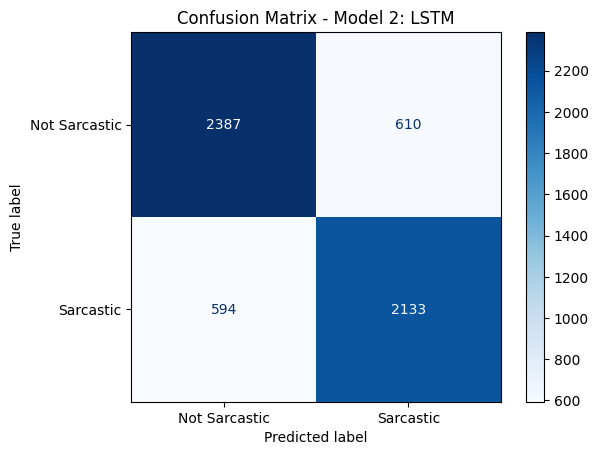

               precision    recall  f1-score   support

Not Sarcastic       0.80      0.80      0.80      2997
    Sarcastic       0.78      0.78      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


Evaluation: Model 3: LSTM + Word2Vec
Test Accuracy: 0.8216 | Test Loss: 0.3993
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


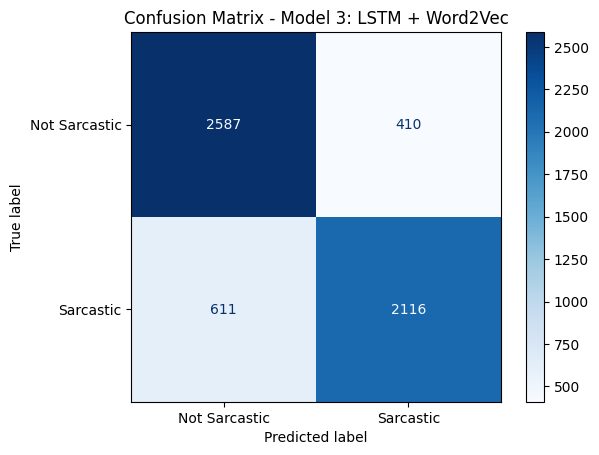

               precision    recall  f1-score   support

Not Sarcastic       0.81      0.86      0.84      2997
    Sarcastic       0.84      0.78      0.81      2727

     accuracy                           0.82      5724
    macro avg       0.82      0.82      0.82      5724
 weighted avg       0.82      0.82      0.82      5724



In [30]:
pred1, acc1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1: SimpleRNN')
pred2, acc2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2: LSTM')
pred3, acc3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3: LSTM + Word2Vec')

# **GUI for real time prediction**

In [31]:
!pip install gradio -q

In [32]:
import gradio as gr

def predict_sarcasm(headline):
    cleaned = clean_text(headline)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    p1 = model1.predict(padded, verbose=0)[0][0]
    p2 = model2.predict(padded, verbose=0)[0][0]
    p3 = model3.predict(padded, verbose=0)[0][0]

    def fmt(p):
        label = "Sarcastic" if p > 0.5 else "Not Sarcastic"
        return f"{label}  (confidence: {p:.2%})"

    return fmt(p1), fmt(p2), fmt(p3)

In [33]:
interface = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(lines=3, placeholder="Enter a tweet..."),
    outputs=[
        gr.Textbox(label="Model 1: SimpleRNN"),
        gr.Textbox(label="Model 2: LSTM"),
        gr.Textbox(label="Model 3: LSTM + Word2Vec"),
    ],
    title="Sarcasm Detection App",
    description="Enter a sentence and detect whether it is sarcastic or not."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3fdce4d9fb7c74480f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
